# 역함수

함수 $f$가 **일대일**이면 역함수 $f^{-1}$가 존재하고

$$
(f \circ f^{-1})(x) = x, \qquad (f^{-1} \circ f)(x) = x
$$

그래프에서는 $y=f(x)$와 $y=f^{-1}(x)$가 **직선 $y=x$에 대해 대칭**


## 1. 역함수가 존재할 조건

- 정의역에서 **일대일**(단사)이어야 함
- 예: $f(x)=2x+1$ (실수 전체) → 역함수 존재
- 예: $g(x)=x^2$ (실수 전체) → 일대일 아님 → 역함수 없음  
  (정의역을 $x\ge 0$으로 제한하면 가능)


## 2. 대수적으로 구하기

절차: $y=f(x)$ → $x$에 대해 풀기 → $x$와 $y$를 바꿔 $y=f^{-1}(x)$로 쓰기.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing()
x, y = sp.symbols('x y')

f_expr = 2*x + 1
# y = 2x+1 → x = (y-1)/2 → f^{-1}(x) = (x-1)/2
eq = sp.Eq(y, f_expr)
solved = sp.solve(eq, x)[0]
finv_expr = solved.subs(y, x)

print("원래 함수 f(x):")
display(f_expr)
print("역함수 f^{-1}(x):")
display(finv_expr)


원래 함수 f(x):


역함수 f^{-1}(x):


**sp.solve(eq, x)**: <br>
=> 방정식에서 $x$ 구하기

**.subs(y, x)**: <br>
=> $x\leftrightarrow y$ 교환 후 표준 표기 $f^{-1}(x)$


## 3. 합성 확인: $f(f^{-1}(x))=x$


In [2]:
fog = sp.simplify(f_expr.subs(x, finv_expr))
gof = sp.simplify(finv_expr.subs(x, f_expr))
print("f(f^{-1}(x)) =", fog)
print("f^{-1}(f(x)) =", gof)


f(f^{-1}(x)) = x
f^{-1}(f(x)) = x


## 4. 그래프: $f$와 $f^{-1}$, $y=x$ 대칭


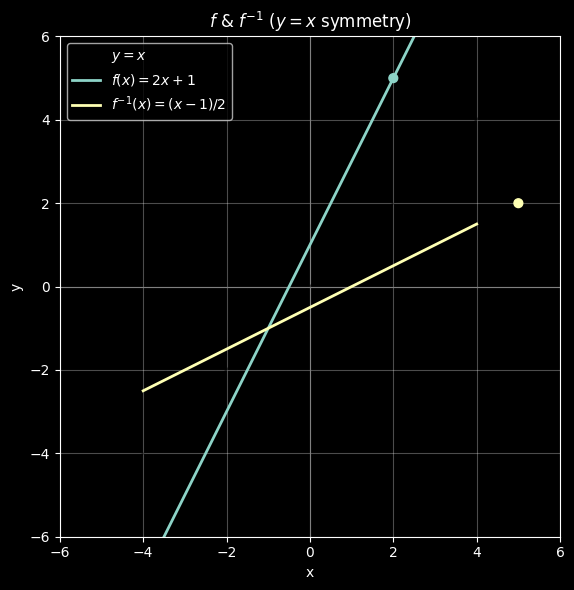

In [5]:
f = sp.lambdify(x, f_expr, 'numpy')
finv = sp.lambdify(x, finv_expr, 'numpy')

xs = np.linspace(-4, 4, 200)
diag = np.linspace(-8, 8, 50)

plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(0, color='gray', lw=0.8)
plt.plot(diag, diag, 'k--', alpha=0.5, label=r'$y=x$')
plt.plot(xs, f(xs), label=r'$f(x)=2x+1$', lw=2)
plt.plot(xs, finv(xs), label=r'$f^{-1}(x)=(x-1)/2$', lw=2)
# 한 점과 대칭점
pt = 2
plt.scatter([pt, f(pt)], [f(pt), pt], c=['C0', 'C1'], zorder=5, s=40)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-6, 6); plt.ylim(-6, 6)
plt.xlabel('x'); plt.ylabel('y')
plt.title(r'$f$ & $f^{-1}$ ($y=x$ symmetry)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**plt.gca().set_aspect('equal')**: <br>
=> 축 비율을 같게 해서 $y=x$ 대칭이 눈에 보이게
